In [106]:
using Pkg
Pkg.activate(dirname(dirname(pwd())))   # activate MyPackage
# Pkg.instantiate()
using Revise
using LMC
using CairoMakie
using LaTeXStrings

using JLD2
include("/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/model/rhombohedral/plotters.jl")
include("/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/model/tbg/hf_plotters.jl")

  Activating project at `~/Documents/Work/PostdocDonosti/Packages/LMC`


plothartreebands (generic function with 1 method)

In [107]:
folder = 2281278
simportedvp = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"vp")
simportedqah = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"qah")

l = LMC.readparams(folder)
p = ParamsHF(paramsHF(1.05, 1,  1),
    μ = 0,
    nf = l.nf[1],
    λ = l.λ[1],
    M = l.M[1],
    v = l.v[1],
    vp = l.vp[1],
    γ =l.γ[1],
    sigmaz = l.sigmaz[1],
    sigmazlayerz = l.sigmazlayerz[1],
    U1 = l.U1[1],
    U2 = l.U2[1],
    J = 0*l.J[1],
    VP =l.VP[1],
    twovalleystwospins= l.twovalleystwospins[1]);



In [108]:
p

ParamsHF
  μ: Float64 0.0
  θ: Float64 1.05
  ν: Int64 1
  nmax: Int64 1
  pointsk: Int64 30
  v: Float64 -7000.0
  vp: Float64 2000.0
  vpp: Float64 -0.0332
  M: Float64 5.0
  γ: Float64 -30.0
  λ: Float64 140.0
  U1: Float64 5.0
  U2: Float64 0.0
  n: Float64 0.0
  nf: Float64 1.0
  sigmaz: Float64 2.5
  sigmazlayerz: Float64 0.0
  layerz: Float64 0.0
  vafek: Float64 0.0
  c2ybreakingmass: Float64 0.0
  J: Float64 0.0
  VP: Bool true
  twovalleys: Bool false
  twovalleystwospins: Bool true
  KIVC: Bool false


In [135]:
# function figureTBGbands(p, of; kpoints = 100, ylims = [-40,40])
#     fig = Figure()
#     ax = Axis(fig[1,1], xlabel = "", ylabel = L"$\text{E [meV]} $")
#     plotbands!(ax, real.(LMC.bands(ParamsHF(p, ν = 1),of, kpoints)))#, ylimits = ylims, color = :black)
#     fig

# end


function lat_TBGbands(;ylims = (-40,40), xlimits = missing, fontsize = 14, linewidth = 2)
    with_theme(merge(theme_latexfonts(), Theme(fontsize = fontsize))) do #
        figureTBGbands(ylims = ylims, xlimits = xlimits, fontsize = fontsize, linewidth = linewidth)   
    end
end

function figureTBGbands(;ylims = (-40,40), xlimits = missing, fontsize = 14, linewidth = 2)
    fig = Figure(size = (600, 400))
    ax1 = Axis(fig[1,1], ylabel = L"$\text{E [meV]}$", xlabelsize = fontsize+2, ylabelsize = fontsize+2) #bands
    ax2 = Axis(fig[2,1], ylabel = L"$\text{E [meV]}$", xlabelsize = fontsize+2, ylabelsize = fontsize+2) #bands
    ga = fig[1:2,2] = GridLayout()

    p = ParamsHF(paramsHF(1.05, 1,  1),
                  μ = 0,
                  nf = 1,
                  λ = 140,
                  M = 5,
                  v = -7e3,
                  vp = 2e3,
                  γ =-30,
                  sigmaz = 0,
                  sigmazlayerz = 0,
                  U1 = 0,
                  U2 = 0,   
                  J = 1,
                  VP =true,
                  twovalleystwospins= true)
                  LMC.plotmybands!(ax1, real.(LMC.bands(ParamsHF(p, μ = 0, sigmaz = 0), ones(8), 101)),
                    ylimits = ylims, color = :black, linewidth = linewidth)
                  LMC.plotmybands!(ax2, real.(LMC.bands(ParamsHF(p, μ = 0, sigmaz = 5), ones(8),  101)), 
                    ylimits = ylims, xlimits = xlimits, color = :black, linewidth = linewidth)
    xlims!(ax1, xlimits)
    hidexdecorations!(ax1, grid = false)
    fig
end



figureTBGbands (generic function with 3 methods)

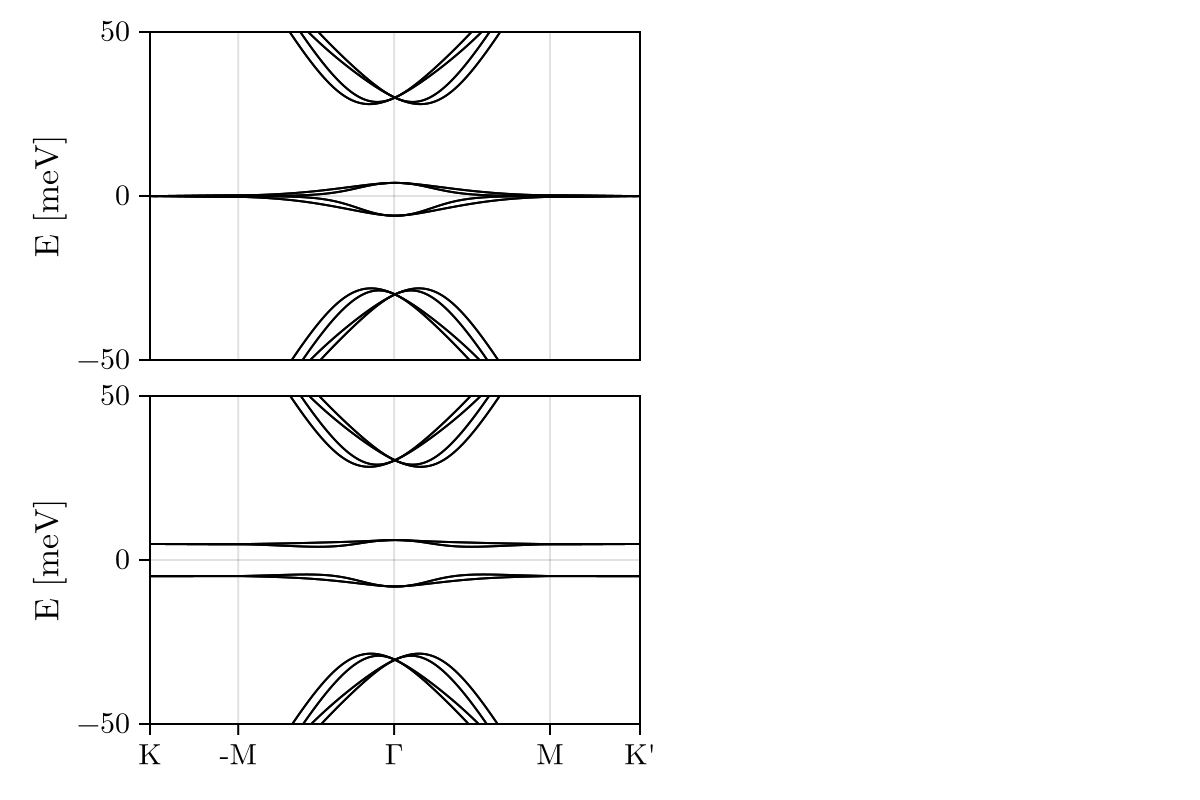

In [138]:
fig = lat_TBGbands(xlimits = [1,277], linewidth = 1, fontsize = 15, ylims = (-50,50))

In [140]:
v = "v2"
save("/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/Figures/FigureTBGbands$(v).pdf", fig)

CairoMakie.Screen{PDF}


In [116]:
using SparseArrays
sparse(real.(LMC.bands(ParamsHF(p, ν = 1), ones(8),100)))

120×275 SparseMatrixCSC{Float64, Int64} with 33000 stored entries:
⎡⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎤
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎣⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⎦

In [29]:
hf_plotbands()

UndefVarError: UndefVarError: `sigmaz` not defined